# Predicting Crime Locality Using Decision Trees

### Research Question and Dataset

This classifcation model uses the Crime Data from 2020 to Present dataset from the Los Angeles Police Derpartment (LAPD). This dataset conforms to Uniform Crime Reporting standards and the version used was last updated Janury 2, 2026. LAPD moved to a different crime reporting standard in 2024 so this particular dataset will not be updated moving forward. The dataset contains 28 columns with 1,004,991 rows, each referring to a particular crime incident.

The research question we are investigating is whether we can predict where a crime occured given the type of crime it is and when it occurred.

Key variables are area, crime code, crime code description, time occured, and date occurred. Area corresponds to one of the 21 LAPD divisons, each pertaining to an LAPD station which serves the area.
Crime code is an internally used code by LAPD to classify crimes. Crime code description shows a human readable description of the crime reported.
Time occurred and date occurred refer to when the crime reported occurred.

[Data Source](https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-Present/2nrs-mtv8/about_data)

[LAPD Areas](https://geohub.lacity.org/datasets/lapd-divisions)

In [9]:
import numpy as np, pandas as pd
from datetime import datetime

lapd = pd.read_csv("Crime_Data_from_2020_to_Present.csv")
cols = ['DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME', 'Crm Cd Desc']
cols_lower = {e: e.lower() for e in cols}
df_low = lapd[cols]
df_low = df_low.rename(columns=cols_lower)
df_low.head()

,date occ,time occ,area,area name,crm cd desc
0,11/07/2020 12:00:00 AM,845,15,N Hollywood,THEFT OF IDENTITY
1,10/18/2020 12:00:00 AM,1845,15,N Hollywood,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT"
2,10/30/2020 12:00:00 AM,1240,9,Van Nuys,THEFT OF IDENTITY
3,12/24/2020 12:00:00 AM,1310,7,Wilshire,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...
4,09/29/2020 12:00:00 AM,1830,14,Pacific,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER)


To extract more information from when a crime occurred, we will perform some transforms to yield a binned categorized time of day and day of the week.

In [10]:
def time_mapper(t):
    if 500 < t <= 700:
        return '5-7AM'
    elif 700 < t <= 930:
        return '7-930AM'
    elif 930 < t <= 1100:
        return '930-11AM'
    elif 1100 < t <= 1230:
        return '11AM-1230PM'
    elif 1230 < t <= 1500:
        return '1230-3PM'
    elif 1500 < t <= 1730:
        return '3-530PM'
    elif 1730 < t <= 1900:
        return '530-7PM'
    elif 1900 < t <= 2130:
        return '7-930PM'
    elif 2130 < t <= 2300: 
        return '930-11PM'
    elif 2300 < t or t <= 200:
        return '11PM-2AM'
    elif 200 < t <= 500:
        return '2-5AM'
    else:
        print(t)

df = df_low.copy()
df['tod'] = df['time occ'].apply(time_mapper)
df['date occ'] = df['date occ'].apply(lambda s: s.split(' ')[0])
df['time occ'] = df['time occ'].apply(lambda i: '0' + str(i) if i < 1000 else str(i))
df['date occ'] = df['date occ'] + ' ' + df['time occ']
df['date occ'] = df['date occ'].apply(lambda x: datetime.strptime(x, '%m/%d/%Y %H%M'))
df['dow'] = df['date occ'].apply(lambda dt: dt.weekday()).map(
    {0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday', 4: 'Friday', 5: 'Saturday', 6: 'Sunday'}
)
df = df.drop(['date occ', 'area name', 'time occ'], axis=1)
df.head()

,area,crm cd desc,tod,dow
0,15,THEFT OF IDENTITY,7-930AM,Saturday
1,15,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",530-7PM,Sunday
2,9,THEFT OF IDENTITY,1230-3PM,Friday
3,7,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,1230-3PM,Thursday
4,14,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),530-7PM,Tuesday


In [77]:
df['tod'].unique()

['7-930AM' '530-7PM' '1230-3PM' '11AM-1230PM' '11PM-2AM' '2-5AM'
 '930-11PM' '3-530PM' '5-7AM' '7-930PM' '930-11AM']


Here we can one hot encode categories and prepare the dataset for modeling.

In [11]:
df_mr = df[['area']].join(pd.get_dummies(df[['crm cd desc', 'tod', 'dow']]))
print(df_mr.shape)
df_mr.head()

(1004991, 159)


,area,crm cd desc_ARSON,crm cd desc_ASSAULT WITH DEADLY WEAPON ON POLICE OFFICER,"crm cd desc_ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",crm cd desc_ATTEMPTED ROBBERY,crm cd desc_BATTERY - SIMPLE ASSAULT,crm cd desc_BATTERY ON A FIREFIGHTER,crm cd desc_BATTERY POLICE (SIMPLE),crm cd desc_BATTERY WITH SEXUAL CONTACT,"crm cd desc_BEASTIALITY, CRIME AGAINST NATURE SEXUAL ASSLT WITH ANIM",...,tod_7-930PM,tod_930-11AM,tod_930-11PM,dow_Friday,dow_Monday,dow_Saturday,dow_Sunday,dow_Thursday,dow_Tuesday,dow_Wednesday
0,15,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,15,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,14,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


### Modeling
Now we train scikit-learn's decision tree model on the cleaned and prepared dataset.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X = df_mr[df_mr.columns.difference(['area'])]
y = df_mr['area']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=641, test_size=0.25)
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

DecisionTreeClassifier()

In [13]:
y_pred = dtc.predict(X_test)

### Model Evaluation

Scikit-learn's classification report will show how the model performs on the test set for each class label.

In [7]:
from sklearn.metrics import classification_report

cr = classification_report(y_test, y_pred)
cr_d = classification_report(y_test, y_pred, output_dict=True)
print(cr)

              precision    recall  f1-score   support

           1       0.12      0.38      0.18     17620
           2       0.06      0.02      0.03     11581
           3       0.09      0.07      0.08     14426
           4       0.08      0.01      0.02      9307
           5       0.08      0.02      0.04     10470
           6       0.10      0.05      0.07     12828
           7       0.10      0.08      0.09     12079
           8       0.08      0.08      0.08     11528
           9       0.06      0.02      0.03     10635
          10       0.08      0.03      0.04     10588
          11       0.06      0.01      0.02     10715
          12       0.10      0.36      0.15     15484
          13       0.08      0.07      0.07     12319
          14       0.10      0.23      0.14     14595
          15       0.09      0.05      0.06     12872
          16       0.10      0.01      0.01      8314
          17       0.06      0.04      0.05     10526
          18       0.09    

Our test accuracy was 10% accurate. Given a 4.7% chance of choosing correctly at random our model performs twice as well as choosing at random which is not spectacular but not nothing.

In [17]:
test_set = df.iloc[X_test.index]
results = pd.DataFrame(data=[y_test, test_set['crm cd desc'], test_set['tod'], test_set['dow'], y_pred == y_test],
                       index=['Area', 'Crime Code Desc', 'Time of Day', 'Weekday', 'Accuracy']).T
#results = results.rename(columns={'0':'Predicted Value', '1':'Accuracy','2':'True Value'})
results['Area'] = results['Area'].astype(str)
results.head()

,Area,Crime Code Desc,Time of Day,Weekday,Accuracy
413823,15,THEFT OF IDENTITY,11AM-1230PM,Tuesday,False
390792,16,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",930-11AM,Monday,False
472543,2,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",1230-3PM,Monday,False
494434,9,PICKPOCKET,530-7PM,Tuesday,False
821188,10,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,930-11PM,Thursday,False


Text(0.5, 1.0, 'Accuracy by Area')

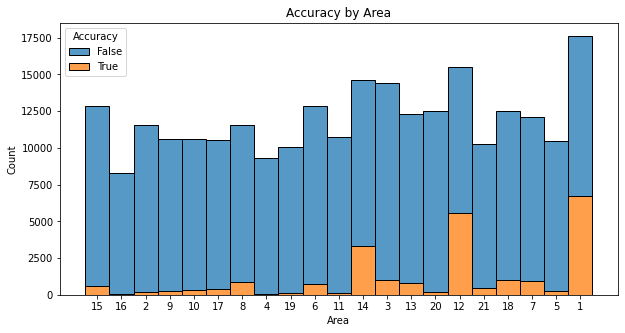

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,5))
sns.histplot(data=results,
            x='Area', hue='Accuracy', multiple='stack', 
             element='bars', legend=True)
plt.title('Accuracy by Area')

The model performs the best on the majority class but quite poorly in general.

Text(0.5, 1.0, 'Accuracy by Crime')

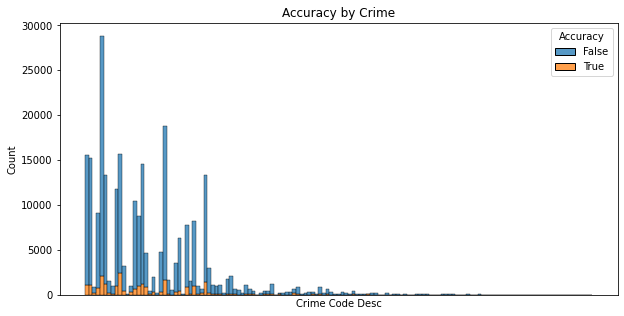

In [19]:
plt.figure(figsize=(10,5))
sns.histplot(data=results,
            x='Crime Code Desc', hue='Accuracy', multiple='stack', 
             element='bars', legend=True)
plt.xticks(ticks=[],labels=[])
plt.title('Accuracy by Crime')

The model is not overly biased toward predicting a specific class of crime, being most accurate on a crime which is not the majority crime class.

Text(0.5, 1.0, 'Accuracy by Weekday')

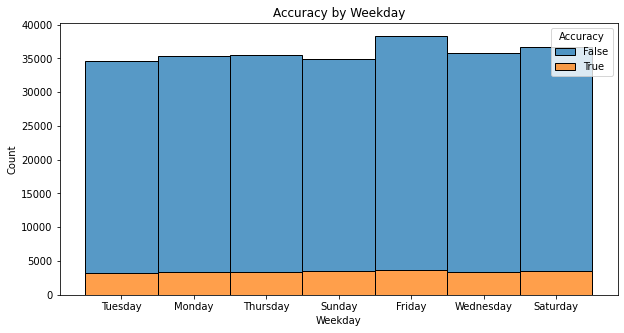

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(data=results,
            x='Weekday', hue='Accuracy', multiple='stack', 
             element='bars', legend=True)
plt.title('Accuracy by Weekday')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

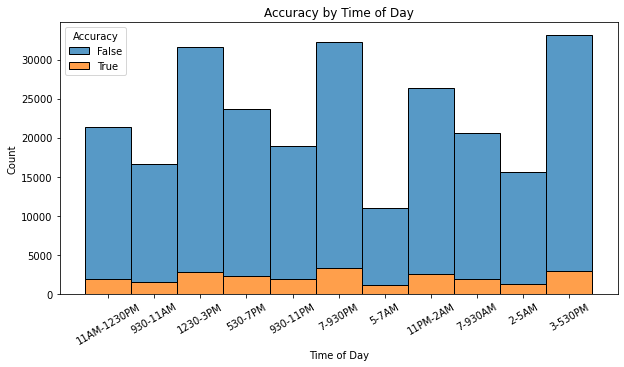

In [79]:
plt.figure(figsize=(10,5))
sns.histplot(data=results,
            x='Time of Day', hue='Accuracy', multiple='stack', 
             element='bars', legend=True)
plt.title('Accuracy by Time of Day')
plt.xticks(rotation=30)

In feature engineering, I had hoped that the day of the week a crime occurred would be helpful in identifying where a crime occurred. As the old saying goes crime never sleeps, it seems to also take no weekends.